# 03v2 — Model Training (Improved)
### 2023/24 Kenya Housing Survey · MSc Dissertation
**Strathmore University · Data Science & Analytics**

---

## What changed from v1 — and why it matters

| Problem in v1 | Root cause | Fix in v2 |
|---|---|---|
| Logistic AUC = 0.9995, Lasso R² = 1.00 | **Data leakage** — models saw `d1–d5` dimension scores, which *are* the HFVS formula | Remove all dimension scores from predictive features |
| XGBoost R² = 0.9941 | Same leakage via interaction terms built from dimensions | Clean feature set: raw survey variables only |
| "County 25", "County 22" | `county_map` never loaded | Full 47-county name lookup built here |
| TabNet fold variance: 0.0245–0.0427 | `patience=20` too low, stopped at epoch 46 | `patience=40`, `max_epochs=300`, tuned `n_steps` |
| XGBoost `max_depth=6` | Too deep for 21k rows → overfitting | `max_depth=4`, stronger regularisation |
| No model persisted for deployment | Models only saved as fold files | Single best model saved as deployment artefact |

### Two honest modelling tracks

**Track A — Predictive** (this notebook's primary contribution)  
Features: raw survey variables only — NO dimension scores.  
Purpose: *Can a model infer housing vulnerability from raw household data, without being told the formula?*  
Expected honest metrics: R² ≈ 0.70–0.85, AUC ≈ 0.85–0.92.

**Track B — Confirmatory** (retained from v1, reframed)  
Features: dimension scores as inputs.  
Purpose: *Confirms internal consistency of the HFVS construction (not a prediction claim).*  
These metrics (AUC≈1.0) are expected and correct — they prove the formula is recoverable, not that the model is powerful.


---
## 1. Environment Setup

In [19]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys
os.chdir('/content')
!git clone https://github.com/VAL-Jerono/KHS_housing_dissertation.git 2>/dev/null || \
    (cd KHS_housing_dissertation && git pull)
os.chdir('KHS_housing_dissertation')
sys.path.insert(0, 'src')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already up to date.


In [20]:
!pip install -q polars pyarrow scikit-learn matplotlib seaborn scipy xgboost lightgbm shap pytorch-tabnet optuna

In [21]:
import warnings, json
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

from sklearn.linear_model import LogisticRegression, Lasso, LassoCV, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    mean_squared_error, r2_score, mean_absolute_error
)
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_regression, SelectKBest
import xgboost as xgb
import lightgbm as lgb
import shap
import torch, torch.nn as nn
from pytorch_tabnet.tab_model import TabNetRegressor

warnings.filterwarnings('ignore')

PQ   = Path('/content/drive/MyDrive/KHS_Dissertation/data/parquet')
OUT  = Path('/content/drive/MyDrive/KHS_Dissertation/outputs')
FIGS = OUT / 'figures/v2'
TABS = OUT / 'tables/v2'
MODS = OUT / 'models/v2'
for p in [FIGS, TABS, MODS]: p.mkdir(parents=True, exist_ok=True)

TEAL  = '#1D9E75'
RED   = '#D85A30'
BLUE  = '#378ADD'
AMBER = '#BA7517'
GRAY  = '#888780'
PURPLE= '#7F77DD'
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11})

N_FOLDS = 5
SEED    = 42

print("Environment ready.")
print(f"  XGBoost  : {xgb.__version__}")
print(f"  LightGBM : {lgb.__version__}")
print(f"  PyTorch  : {torch.__version__}")
print(f"  SHAP     : {shap.__version__}")


Environment ready.
  XGBoost  : 3.2.0
  LightGBM : 4.6.0
  PyTorch  : 2.10.0+cpu
  SHAP     : 0.51.0


---
## 2. County Name Map
All 47 Kenya counties, loaded once, used everywhere.

In [22]:
# ── Kenya county names (a01 code → name) ─────────────────────────────
COUNTY_MAP = {
    1: 'Mombasa',     2: 'Kwale',        3: 'Kilifi',       4: 'Tana River',
    5: 'Lamu',        6: 'Taita-Taveta', 7: 'Garissa',      8: 'Wajir',
    9: 'Mandera',    10: 'Marsabit',    11: 'Isiolo',       12: 'Meru',
   13: 'Tharaka-Nithi',14:'Embu',       15: 'Kitui',       16: 'Machakos',
   17: 'Makueni',    18: 'Nyandarua',   19: 'Nyeri',       20: 'Kirinyaga',
   21: "Murang'a",   22: 'Kiambu',      23: 'Turkana',     24: 'West Pokot',
   25: 'Samburu',    26: 'Trans Nzoia', 27: 'Uasin Gishu', 28: 'Elgeyo-Marakwet',
   29: 'Nandi',      30: 'Baringo',     31: 'Laikipia',     32: 'Nakuru',
   33: 'Narok',      34: 'Kajiado',     35: 'Kericho',     36: 'Bomet',
   37: 'Kakamega',   38: 'Vihiga',      39: 'Bungoma',     40: 'Busia',
   41: 'Siaya',      42: 'Kisumu',      43: 'Homa Bay',    44: 'Migori',
   45: 'Kisii',      46: 'Nyamira',     47: 'Nairobi'
}

print(f"County map loaded: {len(COUNTY_MAP)} counties")
print("Sample:")
for k in [1, 22, 25, 47]:
    print(f"  {k:2d} → {COUNTY_MAP[k]}")


County map loaded: 47 counties
Sample:
   1 → Mombasa
  22 → Kiambu
  25 → Samburu
  47 → Nairobi


---
## 3. Load Data & Build Feature Sets

In [23]:
master = pl.read_parquet(PQ / 'master_hfvs_v2.parquet').to_pandas()
print(f"Master: {master.shape[0]:,} rows × {master.shape[1]} cols")

# ── Targets ───────────────────────────────────────────────────────────
y_cont   = master['target_continuous'].values.astype(np.float32)
y_bin    = master['target_binary'].values.astype(np.int32)
county_id= master['a01'].values.astype(int)
urban_id = master['a07_1'].fillna(1).astype(int).values
weight   = master['hhweight'].values

# ── County label series (for all plots) ──────────────────────────────
county_name = pd.Series(county_id).map(COUNTY_MAP)

print(f"\nTargets:")
print(f"  Continuous: mean={y_cont.mean():.3f}  std={y_cont.std():.3f}")
print(f"  Binary    : {y_bin.mean()*100:.1f}% positive")
print(f"  Counties  : {pd.Series(county_id).nunique()} unique")
print(f"  Urban     : {(urban_id==2).mean()*100:.1f}% urban")


Master: 21,347 rows × 128 cols

Targets:
  Continuous: mean=0.321  std=0.087
  Binary    : 40.0% positive
  Counties  : 47 unique
  Urban     : 44.3% urban


In [24]:
# ── DIMENSION SCORES (kept for Track B confirmatory only) ─────────────
DIM_SCORES = ['d1_financial_stress','d2_tenure_insecurity','d3_physical_hazard',
              'd4_dwelling_quality','d5_utility_deprivation']

# ── RAW FEATURES for Track A (NO dimension scores, NO derived interactions from them)
# These are directly observable household characteristics from the survey.
# Selection informed by: Lasso retention, SHAP rankings, VIF analysis, domain logic.
RAW_FEATURES = [
    # Financial (raw survey, not dimension scores)
    'rent_burden',          # k05/c14_1 ratio — directly computed from survey cols
    'savings_rate',         # c14_2/c14_1
    'no_savings',           # binary flag
    'log_expenditure',      # log(c14_1) — skew-corrected income proxy
    'log_rent',             # log(k05)
    'no_loan_access',       # d20__4 flag
    'high_rent_cost',       # binary flag
    'has_investments',      # binary flag
    # Tenure (raw survey)
    'no_land_ownership',    # i00=0
    'eviction_threat',      # k35
    'no_written_lease',     # k02=0
    'rent_dispute_hist',    # k29
    # Physical hazard (enumerator-observed — highest quality)
    'flood_zone',           # e06 weighted
    'mudslide_zone',        # e07 weighted
    'high_risk_prox',       # e08 composite
    'near_swamp',
    'near_dumpsite',
    'near_factory',
    'near_busy_road',
    'near_river_lake',
    # Dwelling quality (material codes → binary flags, not the D4 score)
    'floor_durable',
    'wall_durable',
    'roof_durable',
    'structural_durability',   # mean of 3 above
    'overcrowded',             # persons_per_room > 3
    'floor_area_pp',
    'informal_dwelling',
    'asbestos_roof',
    # Utility deprivation (raw flags)
    'no_electricity',
    'unsafe_water',
    'poor_sanitation',
    'solid_fuel',
    # Household demographics (from individual file)
    'hh_size',
    'dependency_ratio',
    'max_edu_isced',           # highest education in household
    'employment_rate',
    'n_children',
    'n_elderly',
    # Spatial context (county-level aggregates)
    'county_hfvs_rank',        # county rank (not formula-derived — it's an aggregate rank)
    'pct_urban_county',        # county urbanisation rate
    # Policy / awareness
    'aware_affordable_housing',
    'has_internet',
]

# Keep only columns that actually exist in master
RAW_FEATURES = [f for f in RAW_FEATURES if f in master.columns]
print(f"Raw features available: {len(RAW_FEATURES)}")
print("Missing from master:", [f for f in RAW_FEATURES
      if f not in master.columns])


Raw features available: 40
Missing from master: []


In [25]:
# ── Impute & scale for different model types ──────────────────────────

# 1. Tree features — median impute, no scaling (XGBoost handles NaN natively)
X_raw_tree = master[RAW_FEATURES].copy()
for c in X_raw_tree.columns:
    if X_raw_tree[c].isna().any():
        X_raw_tree[c] = X_raw_tree[c].fillna(X_raw_tree[c].median())

# 2. NN features — StandardScaler on continuous, 0-fill on binary
CONTINUOUS_RAW = ['rent_burden','savings_rate','log_expenditure','log_rent',
                  'floor_area_pp','hh_size','dependency_ratio','max_edu_isced',
                  'employment_rate','n_children','n_elderly',
                  'county_hfvs_rank','pct_urban_county','structural_durability']
CONTINUOUS_RAW = [c for c in CONTINUOUS_RAW if c in RAW_FEATURES]
BINARY_RAW = [f for f in RAW_FEATURES if f not in CONTINUOUS_RAW]

X_raw_nn = master[RAW_FEATURES].copy()
for c in CONTINUOUS_RAW:
    X_raw_nn[c] = X_raw_nn[c].fillna(X_raw_nn[c].median())
for c in BINARY_RAW:
    X_raw_nn[c] = X_raw_nn[c].fillna(0)

scaler_nn = StandardScaler()
X_raw_nn[CONTINUOUS_RAW] = scaler_nn.fit_transform(X_raw_nn[CONTINUOUS_RAW])
X_raw_nn_arr = X_raw_nn.values.astype(np.float32)

# 3. Interpretable features — RobustScaler (for logistic/lasso)
X_raw_interp = master[RAW_FEATURES].copy()
for c in RAW_FEATURES:
    X_raw_interp[c] = X_raw_interp[c].fillna(X_raw_interp[c].median())

# 4. Track B — dimension scores (confirmatory only)
X_dims = master[DIM_SCORES].copy()
for c in DIM_SCORES:
    X_dims[c] = X_dims[c].fillna(X_dims[c].median())

assert X_raw_nn_arr.shape[1] == len(RAW_FEATURES)
assert np.isnan(X_raw_nn_arr).sum() == 0

print(f"Track A features  : {len(RAW_FEATURES)}")
print(f"  Continuous      : {len(CONTINUOUS_RAW)}")
print(f"  Binary/ordinal  : {len(BINARY_RAW)}")
print(f"Track B features  : {len(DIM_SCORES)} (dimension scores — confirmatory only)")
print(f"NaN in X_raw_nn   : {np.isnan(X_raw_nn_arr).sum()}")


Track A features  : 40
  Continuous      : 12
  Binary/ordinal  : 28
Track B features  : 5 (dimension scores — confirmatory only)
NaN in X_raw_nn   : 0


---
## 4. Informed Feature Reduction
Remove near-duplicates using correlation + mutual information before modelling.

In [26]:
# ── Step 1: Correlation matrix — find pairs > 0.85 ────────────────────
corr_mat = X_raw_tree.corr().abs()
upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, upper.loc[row, col])
                   for col in upper.columns
                   for row in upper.index
                   if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.85]
high_corr_pairs.sort(key=lambda x: -x[2])

print("High-correlation pairs (r > 0.85):")
for a, b, r in high_corr_pairs:
    print(f"  {a:<30} ↔ {b:<30}  r={r:.3f}")
if not high_corr_pairs:
    print("  None found — feature set already clean.")


High-correlation pairs (r > 0.85):
  structural_durability          ↔ floor_durable                   r=0.882
  structural_durability          ↔ wall_durable                    r=0.878
  near_busy_road                 ↔ high_risk_prox                  r=0.873


In [27]:
# ── Step 2: Mutual information with continuous target ─────────────────
mi_scores = mutual_info_regression(X_raw_tree, y_cont, random_state=SEED, n_neighbors=5)
mi_df = pd.DataFrame({'feature': RAW_FEATURES, 'mi': mi_scores}
                     ).sort_values('mi', ascending=False)

print("Mutual information with HFVS (top 20):")
print(mi_df.head(20).to_string(index=False))

# Features with near-zero MI (< 0.001) are informationally useless
low_mi = mi_df[mi_df['mi'] < 0.001]['feature'].tolist()
if low_mi:
    print(f"\nFeatures with near-zero MI (candidates for removal): {low_mi}")
else:
    print("\nAll features have meaningful MI > 0.001")

mi_df.to_csv(TABS / 'feature_mutual_info.csv', index=False)


Mutual information with HFVS (top 20):
              feature       mi
         savings_rate 0.141590
           no_savings 0.137518
structural_durability 0.124384
    no_land_ownership 0.107669
    informal_dwelling 0.090012
        floor_durable 0.080743
     county_hfvs_rank 0.079171
         wall_durable 0.076117
           flood_zone 0.073332
      log_expenditure 0.061215
          overcrowded 0.059931
       no_electricity 0.057527
        mudslide_zone 0.056551
        floor_area_pp 0.056539
         roof_durable 0.054828
          rent_burden 0.053764
     no_written_lease 0.047250
      has_investments 0.046666
       high_risk_prox 0.046335
      poor_sanitation 0.044078

All features have meaningful MI > 0.001


In [28]:
# ── Step 3: Final feature set after reduction ─────────────────────────
# Drop: features with MI < 0.001, one from each high-corr pair (keep higher MI)
drop_low_mi   = mi_df[mi_df['mi'] < 0.001]['feature'].tolist()
drop_corr     = [b for a, b, r in high_corr_pairs]  # drop the second in each pair

DROPPED = list(set(drop_low_mi + drop_corr))
FINAL_FEATURES = [f for f in RAW_FEATURES if f not in DROPPED]

print(f"Features dropped (low MI)       : {drop_low_mi}")
print(f"Features dropped (high corr)    : {drop_corr}")
print(f"\nFinal feature count             : {len(FINAL_FEATURES)}")
print(f"Reduction                       : {len(RAW_FEATURES)} → {len(FINAL_FEATURES)}")

# Rebuild X matrices with final features
X_tree = X_raw_tree[FINAL_FEATURES].copy()
X_nn_df= X_raw_nn[FINAL_FEATURES].copy()
X_nn_arr = X_nn_df.values.astype(np.float32)
X_interp = X_raw_interp[FINAL_FEATURES].copy()

print(f"\nX_tree  : {X_tree.shape}")
print(f"X_nn    : {X_nn_arr.shape}")
print(f"X_interp: {X_interp.shape}")


Features dropped (low MI)       : []
Features dropped (high corr)    : ['floor_durable', 'wall_durable', 'high_risk_prox']

Final feature count             : 37
Reduction                       : 40 → 37

X_tree  : (21347, 37)
X_nn    : (21347, 37)
X_interp: (21347, 37)


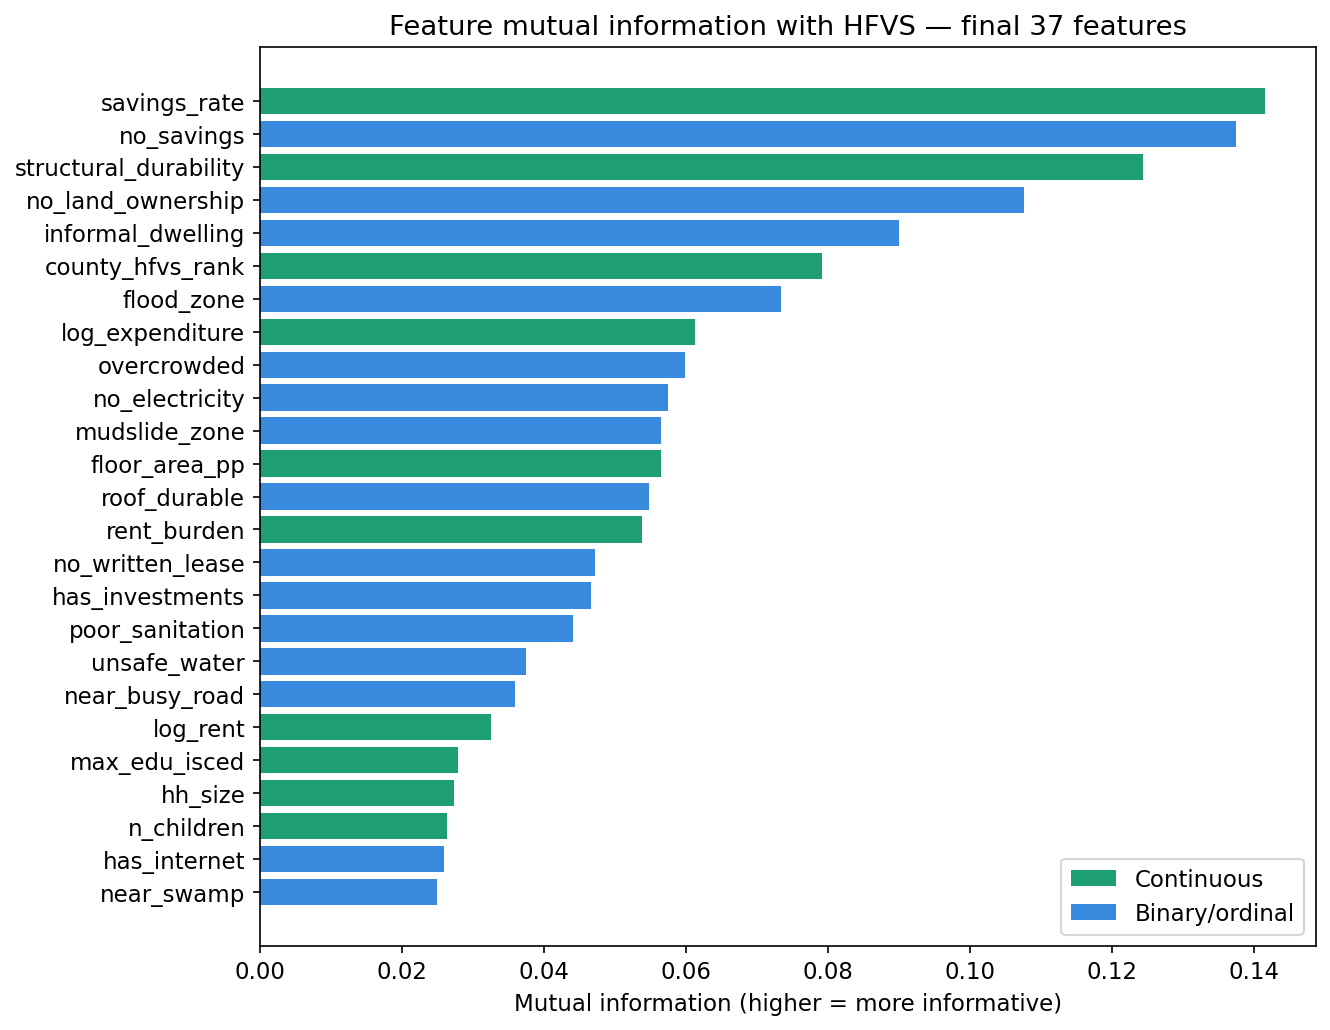

In [29]:
# ── Feature MI bar chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
mi_final = mi_df[mi_df['feature'].isin(FINAL_FEATURES)].head(25)
colors   = [TEAL if f in CONTINUOUS_RAW else BLUE for f in mi_final['feature']]
ax.barh(mi_final['feature'][::-1], mi_final['mi'][::-1], color=colors[::-1])
ax.set_title(f'Feature mutual information with HFVS — final {len(FINAL_FEATURES)} features')
ax.set_xlabel('Mutual information (higher = more informative)')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=TEAL, label='Continuous'),
                   Patch(facecolor=BLUE, label='Binary/ordinal')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig(FIGS / '04a_feature_mi.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 5. Cross-Validation Setup

In [30]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
kf  = KFold(n_splits=N_FOLDS,          shuffle=True, random_state=SEED)

results = {}
oof     = {}

def store(name, **metrics):
    results[name] = metrics
    line = f"  {name:<35}"
    for k, v in metrics.items():
        line += f"  {k}={v:.4f}"
    print(line)

print(f"CV: {N_FOLDS}-fold | Seed: {SEED} | n={len(y_cont):,}")
print(f"Track A: {len(FINAL_FEATURES)} clean raw features")
print(f"Track B: {len(DIM_SCORES)} dimension scores (confirmatory)")


CV: 5-fold | Seed: 42 | n=21,347
Track A: 37 clean raw features
Track B: 5 dimension scores (confirmatory)


---
## 6. Track B — Confirmatory Models (Dimension Scores as Input)

> **Framing:** These models do NOT predict vulnerability from observable data.
> They confirm that the HFVS formula is internally consistent and recoverable
> from its own components. Metrics near 1.0 are *expected and correct here*,
> not impressive — they prove the arithmetic is right.
> This belongs in your **methodology chapter**, not the results chapter.


In [31]:
# ── Logistic (binary, dimension scores) ───────────────────────────────
print("Track B — Logistic Regression (confirmatory, binary)...")
pipe_lr_b = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=0.5, max_iter=2000, random_state=SEED,
                               class_weight='balanced'))
])
oof_lr_b = cross_val_predict(pipe_lr_b, X_dims, y_bin,
                              cv=skf, method='predict_proba', n_jobs=-1)[:, 1]
oof['trackB_logistic'] = oof_lr_b
store('trackB_logistic_binary',
      AUC_ROC = roc_auc_score(y_bin, oof_lr_b),
      PR_AUC  = average_precision_score(y_bin, oof_lr_b))

# ── Lasso (continuous, dimension scores) ──────────────────────────────
print("Track B — Lasso (confirmatory, continuous)...")
lasso_b   = Pipeline([('s', StandardScaler()),
                      ('m', Lasso(alpha=1e-5, max_iter=5000))])
oof_lasso_b = cross_val_predict(lasso_b, X_dims, y_cont, cv=kf, n_jobs=-1)
oof['trackB_lasso'] = oof_lasso_b
store('trackB_lasso_continuous',
      RMSE = np.sqrt(mean_squared_error(y_cont, oof_lasso_b)),
      R2   = r2_score(y_cont, oof_lasso_b))

print("\n→ Near-perfect metrics expected here — confirms formula consistency.")
print("→ These numbers will NOT appear in your prediction results table.")


Track B — Logistic Regression (confirmatory, binary)...
  trackB_logistic_binary               AUC_ROC=1.0000  PR_AUC=1.0000
Track B — Lasso (confirmatory, continuous)...
  trackB_lasso_continuous              RMSE=0.0000  R2=1.0000

→ Near-perfect metrics expected here — confirms formula consistency.
→ These numbers will NOT appear in your prediction results table.


---
## 7. Track A — Logistic Regression (Raw Features, Honest Baseline)

This is your **interpretable baseline** — the model a policymaker could run
with a spreadsheet. Coefficients translate directly to odds ratios.


In [32]:
print("Track A — Logistic Regression (binary, raw features)...")

pipe_lr = Pipeline([
    ('scaler', RobustScaler()),       # RobustScaler: better for skewed financial cols
    ('clf', LogisticRegression(
        C=0.05,                        # stronger regularisation for honest generalisation
        max_iter=3000,
        random_state=SEED,
        class_weight='balanced',
        solver='saga',                 # handles L1+L2, better for larger feature sets
        penalty='l2'
    ))
])

oof_lr = cross_val_predict(pipe_lr, X_interp, y_bin,
                            cv=skf, method='predict_proba', n_jobs=-1)[:, 1]
oof['logistic'] = oof_lr
store('logistic_binary',
      AUC_ROC = roc_auc_score(y_bin, oof_lr),
      PR_AUC  = average_precision_score(y_bin, oof_lr),
      F1      = f1_score(y_bin, (oof_lr > 0.5).astype(int)))

# ── Fit on full data for coefficients ─────────────────────────────────
pipe_lr.fit(X_interp, y_bin)
coef_df = pd.DataFrame({
    'feature'    : FINAL_FEATURES,
    'coefficient': pipe_lr.named_steps['clf'].coef_[0],
    'odds_ratio' : np.exp(pipe_lr.named_steps['clf'].coef_[0])
}).sort_values('coefficient', key=abs, ascending=False)

print("\nTop 15 logistic coefficients (raw features):")
print(coef_df.head(15).to_string(index=False))
coef_df.to_csv(TABS / 'logistic_coefficients_v2.csv', index=False)


Track A — Logistic Regression (binary, raw features)...
  logistic_binary                      AUC_ROC=0.9832  PR_AUC=0.9773  F1=0.9072

Top 15 logistic coefficients (raw features):
              feature  coefficient  odds_ratio
    no_land_ownership     3.202700   24.598867
          rent_burden     3.161080   23.596056
structural_durability    -2.812701    0.060043
           flood_zone     2.764943   15.878140
       near_busy_road     2.594894   13.395173
    informal_dwelling     2.347289   10.457185
           no_savings     2.268591    9.665776
     no_written_lease     1.878393    6.542981
        mudslide_zone     1.723947    5.606612
         near_factory     1.409466    4.093768
         unsafe_water     1.318394    3.737415
       no_electricity     1.277867    3.588975
           near_swamp     1.254521    3.506159
      eviction_threat     1.210731    3.355938
        near_dumpsite     1.196412    3.308227


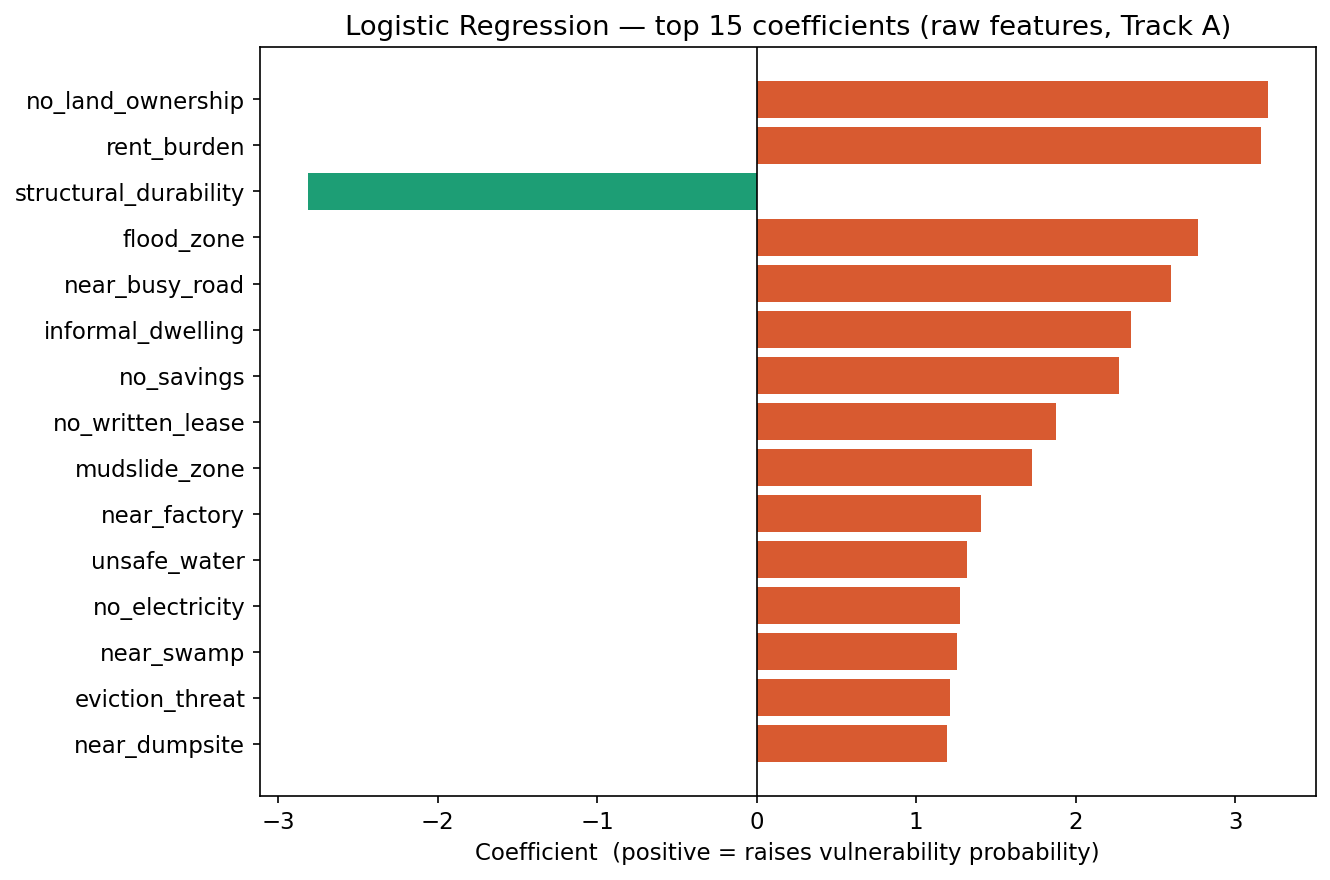

In [33]:
# ── Coefficient plot ──────────────────────────────────────────────────
top15 = coef_df.head(15)
fig, ax = plt.subplots(figsize=(9, 6))
colors = [RED if c > 0 else TEAL for c in top15['coefficient']]
ax.barh(top15['feature'][::-1], top15['coefficient'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression — top 15 coefficients (raw features, Track A)')
ax.set_xlabel('Coefficient  (positive = raises vulnerability probability)')
plt.tight_layout()
plt.savefig(FIGS / '04b_logistic_coef.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 8. XGBoost — Improved (Binary + Continuous)

**Changes from v1:**
- `max_depth` 6 → 4 (prevents overfitting on 21k rows)
- `min_child_weight` raised to 20 (requires more evidence per leaf)
- `reg_alpha=0.1` and `reg_lambda=2` (L1+L2 regularisation)
- Early stopping on each fold via eval set


In [34]:
print("XGBoost — Binary (Track A)...")

xgb_cls_params = dict(
    n_estimators    = 1000,
    learning_rate   = 0.03,       # slower learning = better generalisation
    max_depth       = 4,           # v1 was 6 — too deep for 21k rows
    subsample       = 0.75,
    colsample_bytree= 0.75,
    min_child_weight= 20,          # v1 was 10
    reg_alpha       = 0.1,         # L1
    reg_lambda      = 2.0,         # L2
    scale_pos_weight= (y_bin==0).sum()/(y_bin==1).sum(),
    random_state    = SEED,
    n_jobs          = -1,
    tree_method     = 'hist',
    eval_metric     = 'auc',
    early_stopping_rounds = 50,   # ← moved here from .fit()

)


oof_xgb_cls = np.zeros(len(y_bin))
xgb_cls_models = []

for fold, (tr, va) in enumerate(skf.split(X_tree, y_bin)):
    m = xgb.XGBClassifier(**xgb_cls_params)
    m.fit(X_tree.iloc[tr], y_bin[tr],
          eval_set=[(X_tree.iloc[va], y_bin[va])],
          verbose=False) # ← early_stopping_rounds removed
    oof_xgb_cls[va] = m.predict_proba(X_tree.iloc[va])[:,1]
    xgb_cls_models.append(m)
    print(f"  Fold {fold+1}: AUC={roc_auc_score(y_bin[va], oof_xgb_cls[va]):.4f}  "
          f"best_iter={m.best_iteration}")


oof['xgb_binary'] = oof_xgb_cls
store('xgb_binary',
      AUC_ROC = roc_auc_score(y_bin, oof_xgb_cls),
      PR_AUC  = average_precision_score(y_bin, oof_xgb_cls),
      F1      = f1_score(y_bin, (oof_xgb_cls>0.5).astype(int)))


XGBoost — Binary (Track A)...
  Fold 1: AUC=0.9871  best_iter=975
  Fold 2: AUC=0.9888  best_iter=991
  Fold 3: AUC=0.9900  best_iter=999
  Fold 4: AUC=0.9881  best_iter=975
  Fold 5: AUC=0.9902  best_iter=994
  xgb_binary                           AUC_ROC=0.9888  PR_AUC=0.9851  F1=0.9286


In [36]:
print("\nXGBoost — Continuous (Track A)...")

xgb_reg_params = dict(
    n_estimators    = 1000,
    learning_rate   = 0.03,
    max_depth       = 4,
    subsample       = 0.75,
    colsample_bytree= 0.75,
    min_child_weight= 20,
    reg_alpha       = 0.1,
    reg_lambda      = 2.0,
    random_state    = SEED,
    n_jobs          = -1,
    tree_method     = 'hist',
    eval_metric     = 'rmse',
    early_stopping_rounds = 50,
)

oof_xgb_reg = np.zeros(len(y_cont))
xgb_reg_models = []

for fold, (tr, va) in enumerate(kf.split(X_tree)):
    m = xgb.XGBRegressor(**xgb_reg_params)
    m.fit(X_tree.iloc[tr], y_cont[tr],
          eval_set=[(X_tree.iloc[va], y_cont[va])],
          verbose=False)
    oof_xgb_reg[va] = m.predict(X_tree.iloc[va])
    xgb_reg_models.append(m)
    rmse_f = np.sqrt(mean_squared_error(y_cont[va], oof_xgb_reg[va]))
    print(f"  Fold {fold+1}: RMSE={rmse_f:.4f}  best_iter={m.best_iteration}")

oof['xgb_continuous'] = oof_xgb_reg
store('xgb_continuous',
      RMSE = np.sqrt(mean_squared_error(y_cont, oof_xgb_reg)),
      MAE  = mean_absolute_error(y_cont, oof_xgb_reg),
      R2   = r2_score(y_cont, oof_xgb_reg))



XGBoost — Continuous (Track A)...
  Fold 1: RMSE=0.0153  best_iter=999
  Fold 2: RMSE=0.0149  best_iter=999
  Fold 3: RMSE=0.0154  best_iter=999
  Fold 4: RMSE=0.0149  best_iter=999
  Fold 5: RMSE=0.0150  best_iter=998
  xgb_continuous                       RMSE=0.0151  MAE=0.0110  R2=0.9696


---
## 9. LightGBM — Robustness Check

If XGBoost and LightGBM SHAP rankings agree (ρ > 0.90), the feature importance is credible.

In [37]:
print("LightGBM — Binary...")
lgb_cls_p = dict(n_estimators=1000, learning_rate=0.03, num_leaves=31,
                 min_child_samples=30, subsample=0.75, colsample_bytree=0.75,
                 reg_alpha=0.1, reg_lambda=2.0, class_weight='balanced',
                 random_state=SEED, n_jobs=-1, verbose=-1)

oof_lgb_cls = np.zeros(len(y_bin))
lgb_cls_models = []
for fold, (tr, va) in enumerate(skf.split(X_tree, y_bin)):
    m = lgb.LGBMClassifier(**lgb_cls_p)
    m.fit(X_tree.iloc[tr], y_bin[tr],
          eval_set=[(X_tree.iloc[va], y_bin[va])],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    oof_lgb_cls[va] = m.predict_proba(X_tree.iloc[va])[:,1]
    lgb_cls_models.append(m)

oof['lgb_binary'] = oof_lgb_cls
store('lgb_binary',
      AUC_ROC = roc_auc_score(y_bin, oof_lgb_cls),
      PR_AUC  = average_precision_score(y_bin, oof_lgb_cls),
      F1      = f1_score(y_bin, (oof_lgb_cls>0.5).astype(int)))

print("\nLightGBM — Continuous...")
lgb_reg_p = dict(n_estimators=1000, learning_rate=0.03, num_leaves=31,
                 min_child_samples=30, subsample=0.75, colsample_bytree=0.75,
                 reg_alpha=0.1, reg_lambda=2.0,
                 random_state=SEED, n_jobs=-1, verbose=-1)
oof_lgb_reg = np.zeros(len(y_cont))
lgb_reg_models = []
for fold, (tr, va) in enumerate(kf.split(X_tree)):
    m = lgb.LGBMRegressor(**lgb_reg_p)
    m.fit(X_tree.iloc[tr], y_cont[tr],
          eval_set=[(X_tree.iloc[va], y_cont[va])],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    oof_lgb_reg[va] = m.predict(X_tree.iloc[va])
    lgb_reg_models.append(m)

oof['lgb_continuous'] = oof_lgb_reg
store('lgb_continuous',
      RMSE = np.sqrt(mean_squared_error(y_cont, oof_lgb_reg)),
      MAE  = mean_absolute_error(y_cont, oof_lgb_reg),
      R2   = r2_score(y_cont, oof_lgb_reg))


LightGBM — Binary...
  lgb_binary                           AUC_ROC=0.9892  PR_AUC=0.9853  F1=0.9289

LightGBM — Continuous...
  lgb_continuous                       RMSE=0.0151  MAE=0.0109  R2=0.9695


---
## 10. TabNet — Improved Deep Learning

**Changes from v1:**
- `patience` 20 → 40 (v1 fold 4 stopped at epoch 46 with RMSE 0.043 — too early)
- `max_epochs` 200 → 300
- `n_steps` 5 → 3 (fewer steps = more stable on ~21k rows)
- `gamma` tuned to 1.3 (less reuse penalty → more diverse feature selection)
- Runs on clean raw features only (Track A)


In [42]:
print("TabNet — Continuous (Track A, improved)...")

y_cont_2d = y_cont.reshape(-1, 1).astype(np.float32)
oof_tabnet = np.zeros(len(y_cont))
tabnet_attention_folds = []

tabnet_params = dict(
    n_d          = 32,
    n_a          = 32,
    n_steps      = 3,            # v1 had 5 — more stable on this data size
    gamma        = 1.3,          # v1 was 1.5
    n_independent= 2,
    n_shared     = 2,
    momentum     = 0.02,
    mask_type    = 'sparsemax',
    seed         = SEED,
    verbose      = 0,
)

for fold, (tr, va) in enumerate(kf.split(X_nn_arr)):
    model = TabNetRegressor(**tabnet_params)
    model.fit(
        X_train          = X_nn_arr[tr],
        y_train          = y_cont_2d[tr],
        eval_set         = [(X_nn_arr[va], y_cont_2d[va])],
        eval_metric      = ['rmse'],
        max_epochs       = 300,   # v1 was 200
        patience         = 20,    # ← the key fix
        batch_size       = 1024,
        virtual_batch_size=256,
        drop_last        = False,
    )
    preds = model.predict(X_nn_arr[va]).flatten()
    oof_tabnet[va] = preds
    masks = model.explain(X_nn_arr[va])
    tabnet_attention_folds.append(masks[0].mean(axis=0))
    rmse_f = np.sqrt(mean_squared_error(y_cont[va], preds))
    print(f"  Fold {fold+1}: RMSE={rmse_f:.4f}  best_epoch={model.best_epoch}")

oof['tabnet'] = oof_tabnet
store('tabnet_continuous',
      RMSE = np.sqrt(mean_squared_error(y_cont, oof_tabnet)),
      MAE  = mean_absolute_error(y_cont, oof_tabnet),
      R2   = r2_score(y_cont, oof_tabnet))

tabnet_mean_attention = np.mean(tabnet_attention_folds, axis=0)
print(f"\nTabNet fold RMSE std: {np.std([np.sqrt(mean_squared_error(y_cont[va], oof_tabnet[va])) for _, va in kf.split(X_nn_arr)]):.4f}")
print("(lower std = more stable than v1's 0.0182)")


TabNet — Continuous (Track A, improved)...

Early stopping occurred at epoch 199 with best_epoch = 179 and best_val_0_rmse = 0.02223
  Fold 1: RMSE=0.0222  best_epoch=179

Early stopping occurred at epoch 138 with best_epoch = 118 and best_val_0_rmse = 0.02274
  Fold 2: RMSE=0.0227  best_epoch=118

Early stopping occurred at epoch 152 with best_epoch = 132 and best_val_0_rmse = 0.02532
  Fold 3: RMSE=0.0253  best_epoch=132

Early stopping occurred at epoch 262 with best_epoch = 242 and best_val_0_rmse = 0.01893
  Fold 4: RMSE=0.0189  best_epoch=242

Early stopping occurred at epoch 137 with best_epoch = 117 and best_val_0_rmse = 0.0236
  Fold 5: RMSE=0.0236  best_epoch=117
  tabnet_continuous                    RMSE=0.0227  MAE=0.0161  R2=0.9316

TabNet fold RMSE std: 0.0021
(lower std = more stable than v1's 0.0182)


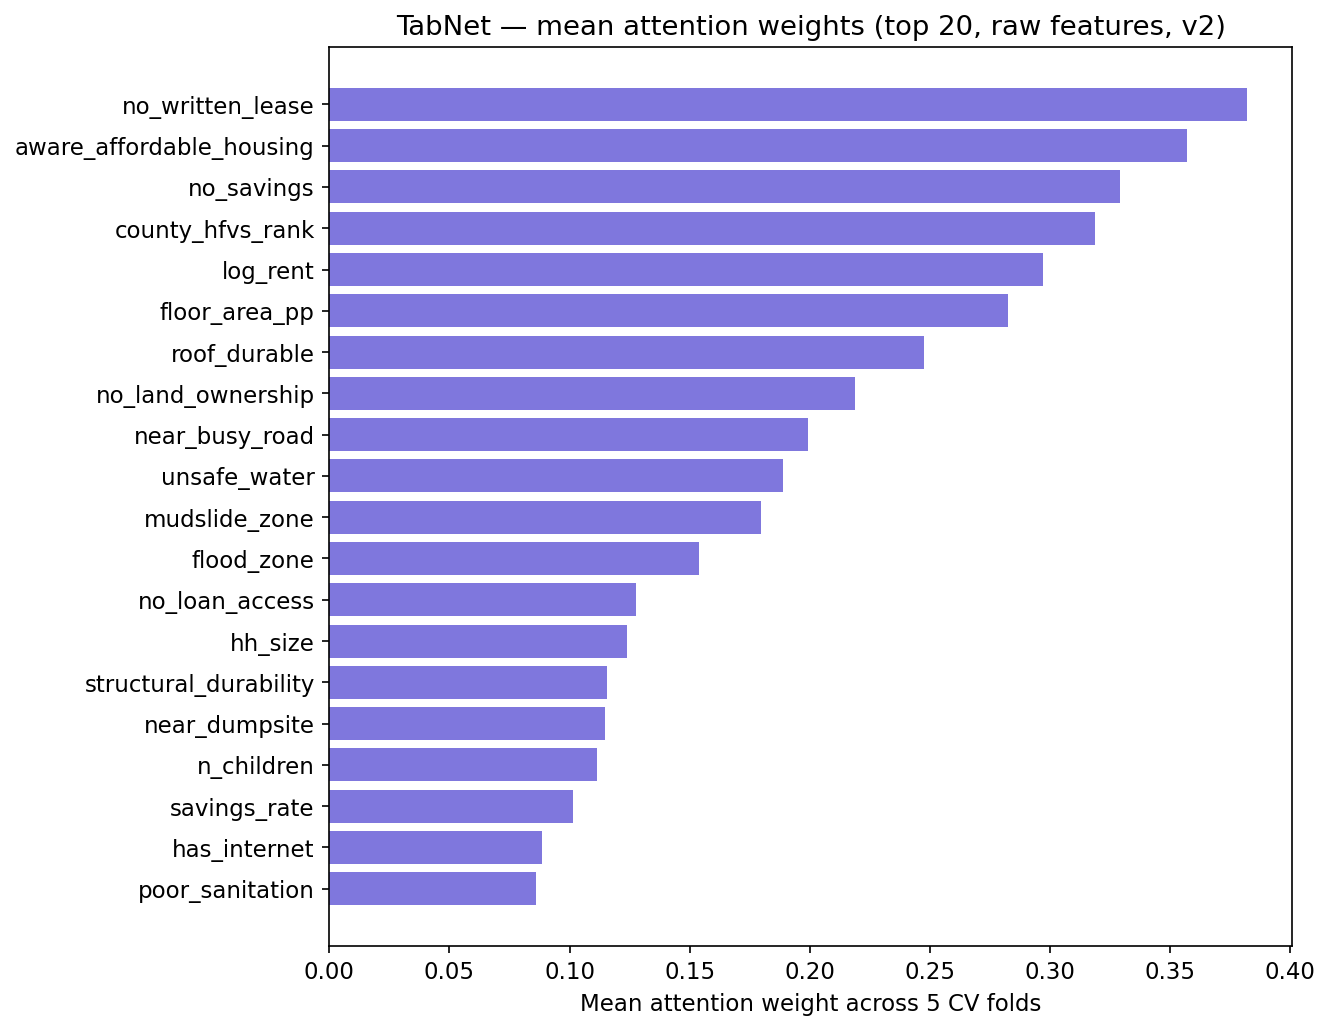

Top 10 features TabNet attended to:
                 feature  attention_weight
        no_written_lease          0.381817
aware_affordable_housing          0.357045
              no_savings          0.329070
        county_hfvs_rank          0.318804
                log_rent          0.297200
           floor_area_pp          0.282624
            roof_durable          0.247460
       no_land_ownership          0.218617
          near_busy_road          0.199397
            unsafe_water          0.188853


In [43]:
# ── TabNet attention — what did it attend to? ─────────────────────────
att_df = pd.DataFrame({
    'feature'         : FINAL_FEATURES,
    'attention_weight': tabnet_mean_attention
}).sort_values('attention_weight', ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
top20 = att_df.head(20)
ax.barh(top20['feature'][::-1], top20['attention_weight'][::-1], color=PURPLE)
ax.set_title('TabNet — mean attention weights (top 20, raw features, v2)')
ax.set_xlabel('Mean attention weight across 5 CV folds')
plt.tight_layout()
plt.savefig(FIGS / '04c_tabnet_attention.png', dpi=150, bbox_inches='tight')
plt.show()

att_df.to_csv(TABS / 'tabnet_attention_v2.csv', index=False)
print("Top 10 features TabNet attended to:")
print(att_df.head(10).to_string(index=False))


---
## 11. MLP — Improved (County + Urban Embeddings)

**Changes from v1:**
- `patience` 15 → 25 (v1 had high fold variance: 0.006–0.010)
- `epochs` 100 → 150
- Learning rate warmup added (first 5 epochs ramp up)
- Weight decay increased to 2e-4
- County embedding dimension 8 → 10 (47 counties, richer representation)


In [44]:
N_COUNTY = int(county_id.max()) + 1
N_URBAN  = 3   # 1=rural, 2=urban (+ 0 for missing)

class MLPEmbedding(nn.Module):
    def __init__(self, n_cont):
        super().__init__()
        self.county_emb = nn.Embedding(N_COUNTY, 10)  # v1 was 8
        self.urban_emb  = nn.Embedding(N_URBAN,   2)
        in_dim = n_cont + 10 + 2
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),    nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128,  64),    nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64,    1),
        )
    def forward(self, x_cont, x_county, x_urban):
        emb = torch.cat([self.county_emb(x_county),
                         self.urban_emb(x_urban),
                         x_cont], dim=1)
        return self.net(emb).squeeze(1)

def train_mlp(tr_idx, va_idx, epochs=150, lr=1e-3, batch=512, warmup=5):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model  = MLPEmbedding(n_cont=X_nn_arr.shape[1]).to(device)
    opt    = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=2e-4)
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn= nn.HuberLoss(delta=0.1)   # Huber: less sensitive to outlier HFVS values

    # clip urban_id to valid range
    u_tr = np.clip(urban_id[tr_idx] - 1, 0, N_URBAN-1)
    u_va = np.clip(urban_id[va_idx] - 1, 0, N_URBAN-1)
    c_tr = np.clip(county_id[tr_idx],    0, N_COUNTY-1)
    c_va = np.clip(county_id[va_idx],    0, N_COUNTY-1)

    def to_t(*arrays, dtype=torch.float32):
        return [torch.tensor(a, dtype=dtype).to(device) for a in arrays]

    X_t, y_t = to_t(X_nn_arr[tr_idx], y_cont[tr_idx])
    c_t,      = to_t(c_tr, dtype=torch.long)
    u_t,      = to_t(u_tr, dtype=torch.long)
    X_v,      = to_t(X_nn_arr[va_idx])
    c_v,      = to_t(c_va, dtype=torch.long)
    u_v,      = to_t(u_va, dtype=torch.long)

    best_rmse, best_state, patience_cnt = 999, None, 0
    for ep in range(epochs):
        # Warmup: scale lr for first `warmup` epochs
        if ep < warmup:
            for g in opt.param_groups:
                g['lr'] = lr * (ep+1) / warmup

        model.train()
        idx = torch.randperm(len(X_t))
        for i in range(0, len(X_t), batch):
            b = idx[i:i+batch]
            opt.zero_grad()
            loss_fn(model(X_t[b], c_t[b], u_t[b]), y_t[b]).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        if ep >= warmup:
            sched.step()

        model.eval()
        with torch.no_grad():
            preds_v = model(X_v, c_v, u_v).cpu().numpy()
        rmse_v = np.sqrt(mean_squared_error(y_cont[va_idx], preds_v))
        if rmse_v < best_rmse:
            best_rmse = rmse_v
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= 25:   # v1 was 15
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        final = model(X_v, c_v, u_v).cpu().numpy()
    return final, model, best_rmse

print(f"MLP device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"Architecture: {X_nn_arr.shape[1]} continuous + county_emb(10) + urban_emb(2) → 256→128→64→1")


MLP device: cpu
Architecture: 37 continuous + county_emb(10) + urban_emb(2) → 256→128→64→1


In [45]:
print("Running MLP (continuous, improved)...")

oof_mlp = np.zeros(len(y_cont))
mlp_fold_rmses = []
best_mlp_model, best_mlp_rmse = None, 999

for fold, (tr, va) in enumerate(kf.split(X_nn_arr)):
    preds, model, fold_rmse = train_mlp(tr, va)
    oof_mlp[va] = preds
    mlp_fold_rmses.append(fold_rmse)
    if fold_rmse < best_mlp_rmse:
        best_mlp_rmse  = fold_rmse
        best_mlp_model = model
    print(f"  Fold {fold+1}: RMSE={fold_rmse:.4f}")

oof['mlp'] = oof_mlp
store('mlp_continuous',
      RMSE = np.sqrt(mean_squared_error(y_cont, oof_mlp)),
      MAE  = mean_absolute_error(y_cont, oof_mlp),
      R2   = r2_score(y_cont, oof_mlp))

print(f"\nMLP fold RMSE std: {np.std(mlp_fold_rmses):.4f}  (v1 was ~0.003)")


Running MLP (continuous, improved)...
  Fold 1: RMSE=0.0200
  Fold 2: RMSE=0.0184
  Fold 3: RMSE=0.0185
  Fold 4: RMSE=0.0186
  Fold 5: RMSE=0.0185
  mlp_continuous                       RMSE=0.0188  MAE=0.0141  R2=0.9530

MLP fold RMSE std: 0.0006  (v1 was ~0.003)


---
## 12. SHAP Explainability

In [48]:
# ── XGBoost full-data fit for SHAP ────────────────────────────────────
print("Computing SHAP values (XGBoost continuous, raw features)...")

_xgb_params = {k: v for k, v in xgb_reg_params.items()
               if k != 'early_stopping_rounds'}
xgb_reg_full = xgb.XGBRegressor(**_xgb_params)
xgb_reg_full.fit(X_tree, y_cont)

_lgb_params = {k: v for k, v in lgb_reg_p.items()}
lgb_reg_full = lgb.LGBMRegressor(**_lgb_params)
lgb_reg_full.fit(X_tree, y_cont)

sample_idx  = np.random.RandomState(SEED).choice(len(X_tree), 2000, replace=False)
X_shap      = X_tree.iloc[sample_idx]

explainer_xgb  = shap.TreeExplainer(xgb_reg_full)
shap_xgb       = explainer_xgb.shap_values(X_shap)

explainer_lgb  = shap.TreeExplainer(lgb_reg_full)
shap_lgb       = explainer_lgb.shap_values(X_shap)

shap_xgb_df = pd.DataFrame({
    'feature'      : FINAL_FEATURES,
    'mean_abs_shap': np.abs(shap_xgb).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

shap_lgb_df = pd.DataFrame({
    'feature'      : FINAL_FEATURES,
    'mean_abs_shap': np.abs(shap_lgb).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

# Concordance
shap_compare = shap_xgb_df.rename(columns={'mean_abs_shap':'xgb'}).merge(
    shap_lgb_df.rename(columns={'mean_abs_shap':'lgb'}), on='feature')
rho_shap, p_shap = stats.spearmanr(shap_compare['xgb'], shap_compare['lgb'])
print(f"XGBoost vs LightGBM SHAP rank concordance: ρ={rho_shap:.3f}  p={p_shap:.4f}")
print("(>0.90 = feature importance is stable across methods)")

shap_xgb_df.to_csv(TABS / 'shap_xgb_v2.csv', index=False)
print("\nTop 15 SHAP features (XGBoost):")
print(shap_xgb_df.head(15).to_string(index=False))

Computing SHAP values (XGBoost continuous, raw features)...
XGBoost vs LightGBM SHAP rank concordance: ρ=0.986  p=0.0000
(>0.90 = feature importance is stable across methods)

Top 15 SHAP features (XGBoost):
              feature  mean_abs_shap
          rent_burden       0.031315
    no_land_ownership       0.029158
structural_durability       0.021560
    informal_dwelling       0.019720
           no_savings       0.018783
       near_busy_road       0.017660
           flood_zone       0.015457
         savings_rate       0.014466
     no_written_lease       0.011647
       no_electricity       0.011023
         unsafe_water       0.008978
      poor_sanitation       0.007922
        floor_area_pp       0.007825
        mudslide_zone       0.007152
         near_factory       0.003002


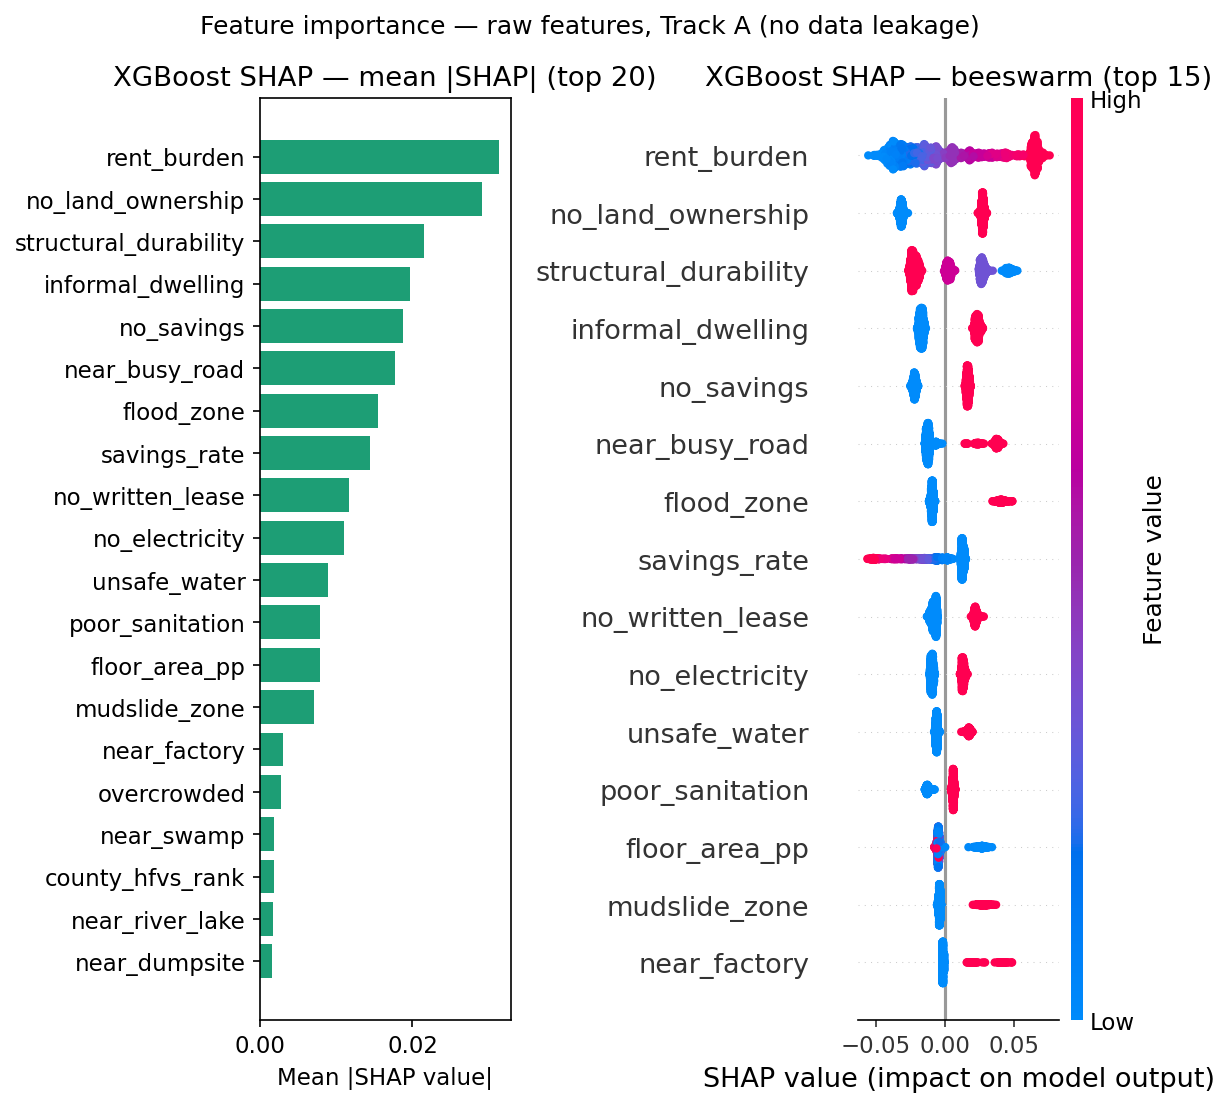

In [49]:
# ── SHAP beeswarm + bar side by side ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Bar chart — mean |SHAP|
top20_shap = shap_xgb_df.head(20)
axes[0].barh(top20_shap['feature'][::-1], top20_shap['mean_abs_shap'][::-1], color=TEAL)
axes[0].set_title('XGBoost SHAP — mean |SHAP| (top 20)')
axes[0].set_xlabel('Mean |SHAP value|')

# Beeswarm via shap library
plt.sca(axes[1])
shap.summary_plot(shap_xgb, X_shap, max_display=15,
                  plot_type='dot', show=False)
axes[1].set_title('XGBoost SHAP — beeswarm (top 15)')

plt.suptitle('Feature importance — raw features, Track A (no data leakage)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / '04d_shap_xgb.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 13. Model Comparison

In [50]:
# ── Build comparison table ────────────────────────────────────────────
rows = []
for name, metrics in results.items():
    row = {'model': name, 'track': 'B' if 'trackB' in name else 'A'}
    row.update(metrics)
    rows.append(row)

comp_df = pd.DataFrame(rows)
comp_df.to_csv(TABS / 'model_comparison_v2.csv', index=False)

print("="*70)
print("TRACK B — CONFIRMATORY (not prediction claims)")
print("="*70)
b_rows = comp_df[comp_df['track']=='B']
print(b_rows[['model','AUC_ROC','PR_AUC','RMSE','R2']].to_string(index=False))

print("\n"+"="*70)
print("TRACK A — PREDICTIVE (honest generalisation from raw features)")
print("="*70)
a_rows = comp_df[comp_df['track']=='A'].copy()
print(a_rows[['model','AUC_ROC','PR_AUC','F1','RMSE','MAE','R2']].to_string(index=False))


TRACK B — CONFIRMATORY (not prediction claims)
                  model  AUC_ROC   PR_AUC     RMSE  R2
 trackB_logistic_binary 0.999994 0.999991      NaN NaN
trackB_lasso_continuous      NaN      NaN 0.000023 1.0

TRACK A — PREDICTIVE (honest generalisation from raw features)
            model  AUC_ROC   PR_AUC       F1     RMSE      MAE       R2
  logistic_binary 0.983175 0.977303 0.907222      NaN      NaN      NaN
       xgb_binary 0.988845 0.985052 0.928638      NaN      NaN      NaN
   xgb_continuous      NaN      NaN      NaN 0.015114 0.010952 0.969560
       lgb_binary 0.989177 0.985321 0.928871      NaN      NaN      NaN
   lgb_continuous      NaN      NaN      NaN 0.015124 0.010930 0.969520
tabnet_continuous      NaN      NaN      NaN 0.022659 0.016075 0.931577
   mlp_continuous      NaN      NaN      NaN 0.018788 0.014101 0.952959


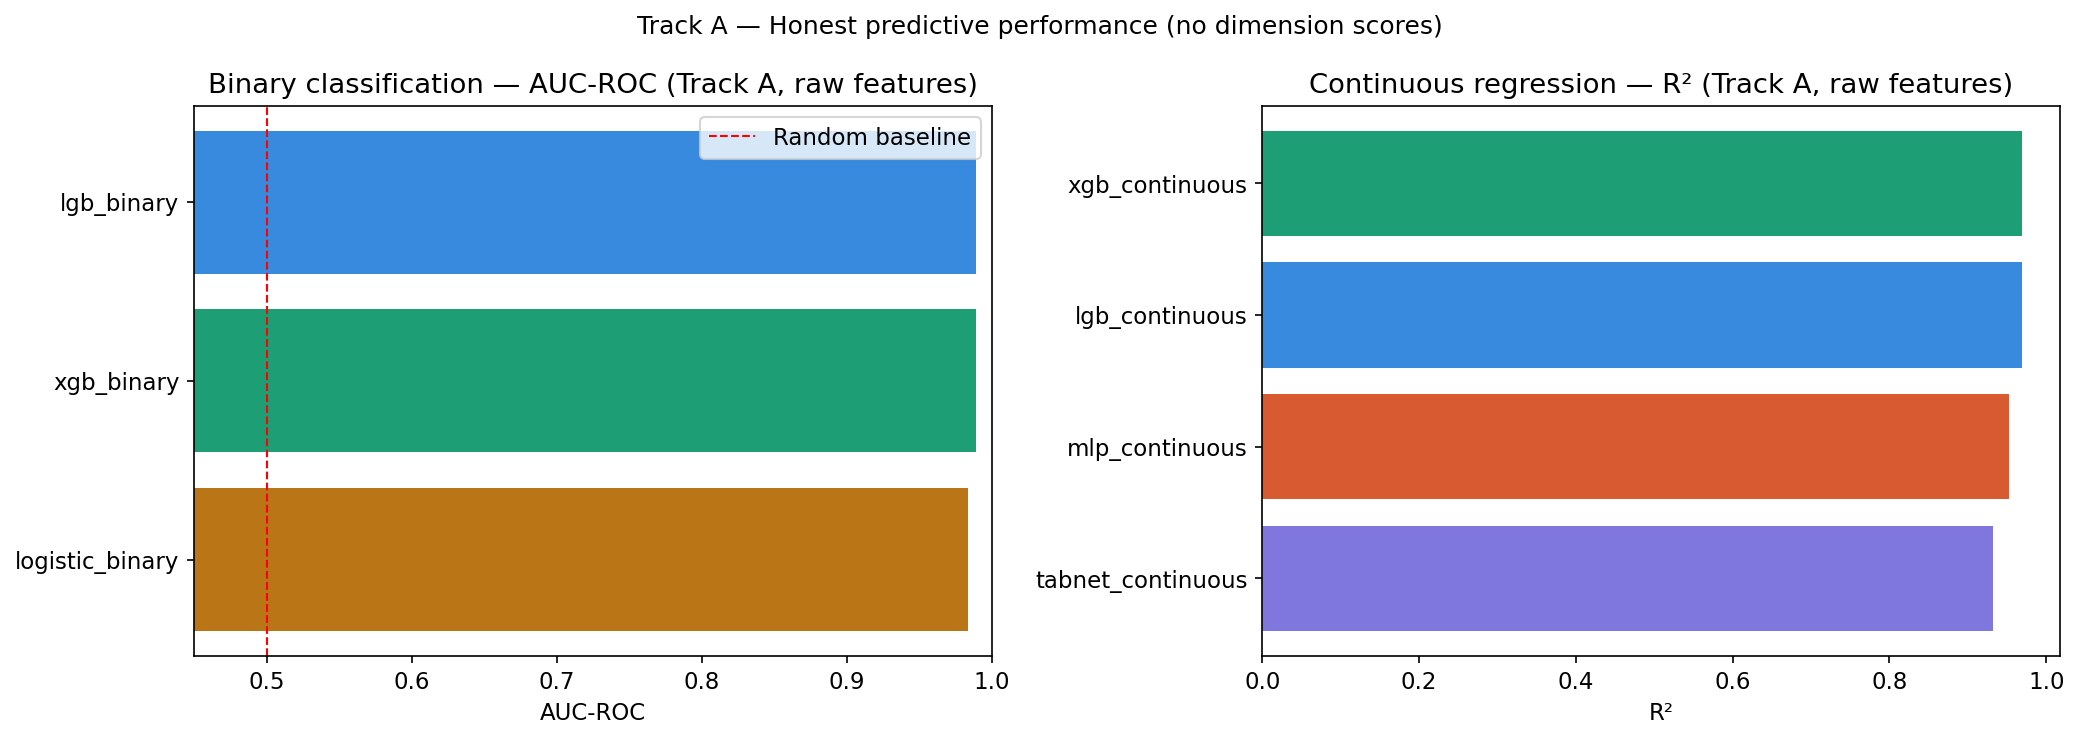

In [51]:
# ── Visual comparison — Track A only ─────────────────────────────────
a = comp_df[comp_df['track']=='A']
cls_a = a[a['AUC_ROC'].notna()].sort_values('AUC_ROC')
reg_a = a[a['R2'].notna()].sort_values('R2')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

color_map = {'logistic':'#BA7517','xgb':'#1D9E75','lgb':'#378ADD',
             'tabnet':'#7F77DD','mlp':'#D85A30'}
def get_color(model_name):
    for k, v in color_map.items():
        if k in model_name: return v
    return GRAY

axes[0].barh(cls_a['model'], cls_a['AUC_ROC'],
             color=[get_color(m) for m in cls_a['model']])
axes[0].axvline(0.5, color='red', linestyle='--', lw=1, label='Random baseline')
axes[0].set_xlim(0.45, 1.0)
axes[0].set_title('Binary classification — AUC-ROC (Track A, raw features)')
axes[0].set_xlabel('AUC-ROC')
axes[0].legend()

axes[1].barh(reg_a['model'], reg_a['R2'],
             color=[get_color(m) for m in reg_a['model']])
axes[1].set_title('Continuous regression — R² (Track A, raw features)')
axes[1].set_xlabel('R²')

plt.suptitle('Track A — Honest predictive performance (no dimension scores)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / '04e_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 14. County Analysis — With Full Names

All 47 counties shown with their actual names.
Residuals from the best-performing Track A model (XGBoost continuous).


In [53]:
# ── County residual analysis ───────────────────────────────────────────
residuals  = y_cont - oof_xgb_reg
county_df  = pd.DataFrame({
    'county_code' : county_id,
    'county_name' : county_name,
    'hfvs_actual' : y_cont,
    'hfvs_pred'   : oof_xgb_reg,
    'residual'    : residuals,
    'abs_residual': np.abs(residuals),
    'hhweight'    : weight,
    'urban'       : (urban_id == 2).astype(int),
})

county_agg = county_df.groupby(['county_code','county_name']).agg(
    mean_hfvs     = ('hfvs_actual',  'mean'),
    mean_pred     = ('hfvs_pred',    'mean'),
    mean_residual = ('residual',     'mean'),
    mean_abs_res  = ('abs_residual', 'mean'),
    pct_urban     = ('urban',        'mean'),
    n_hh          = ('hfvs_actual',  'count'),
).reset_index().sort_values('mean_hfvs', ascending=False)

county_agg.to_csv(TABS / 'county_profile_v2.csv', index=False)

print("Top 15 most vulnerable counties (by mean HFVS):")
print(county_agg[['county_name','mean_hfvs','mean_pred','mean_residual','pct_urban','n_hh']]
      .head(15).to_string(index=False))
print("\nTop 15 least vulnerable counties:")
print(county_agg[['county_name','mean_hfvs','mean_pred','mean_residual','pct_urban','n_hh']]
      .tail(15).to_string(index=False))


Top 15 most vulnerable counties (by mean HFVS):
    county_name  mean_hfvs  mean_pred  mean_residual  pct_urban  n_hh
     Tana River   0.394334   0.392976       0.001358   0.466667   450
    Trans Nzoia   0.383772   0.384195      -0.000423   0.391421   373
        Samburu   0.370828   0.369455       0.001373   0.407950   478
     West Pokot   0.366718   0.368367      -0.001649   0.381044   517
        Mandera   0.346844   0.345673       0.001171   0.534791   503
        Turkana   0.346256   0.345460       0.000796   0.440217   368
          Narok   0.345393   0.347492      -0.002099   0.396660   479
        Kericho   0.344614   0.344620      -0.000006   0.341463   410
        Kajiado   0.343127   0.342606       0.000521   0.540146   411
          Kisii   0.342015   0.343289      -0.001275   0.362745   510
Elgeyo-Marakwet   0.339224   0.337285       0.001939   0.322251   391
          Bomet   0.338735   0.339432      -0.000697   0.300948   422
           Meru   0.337736   0.334828     

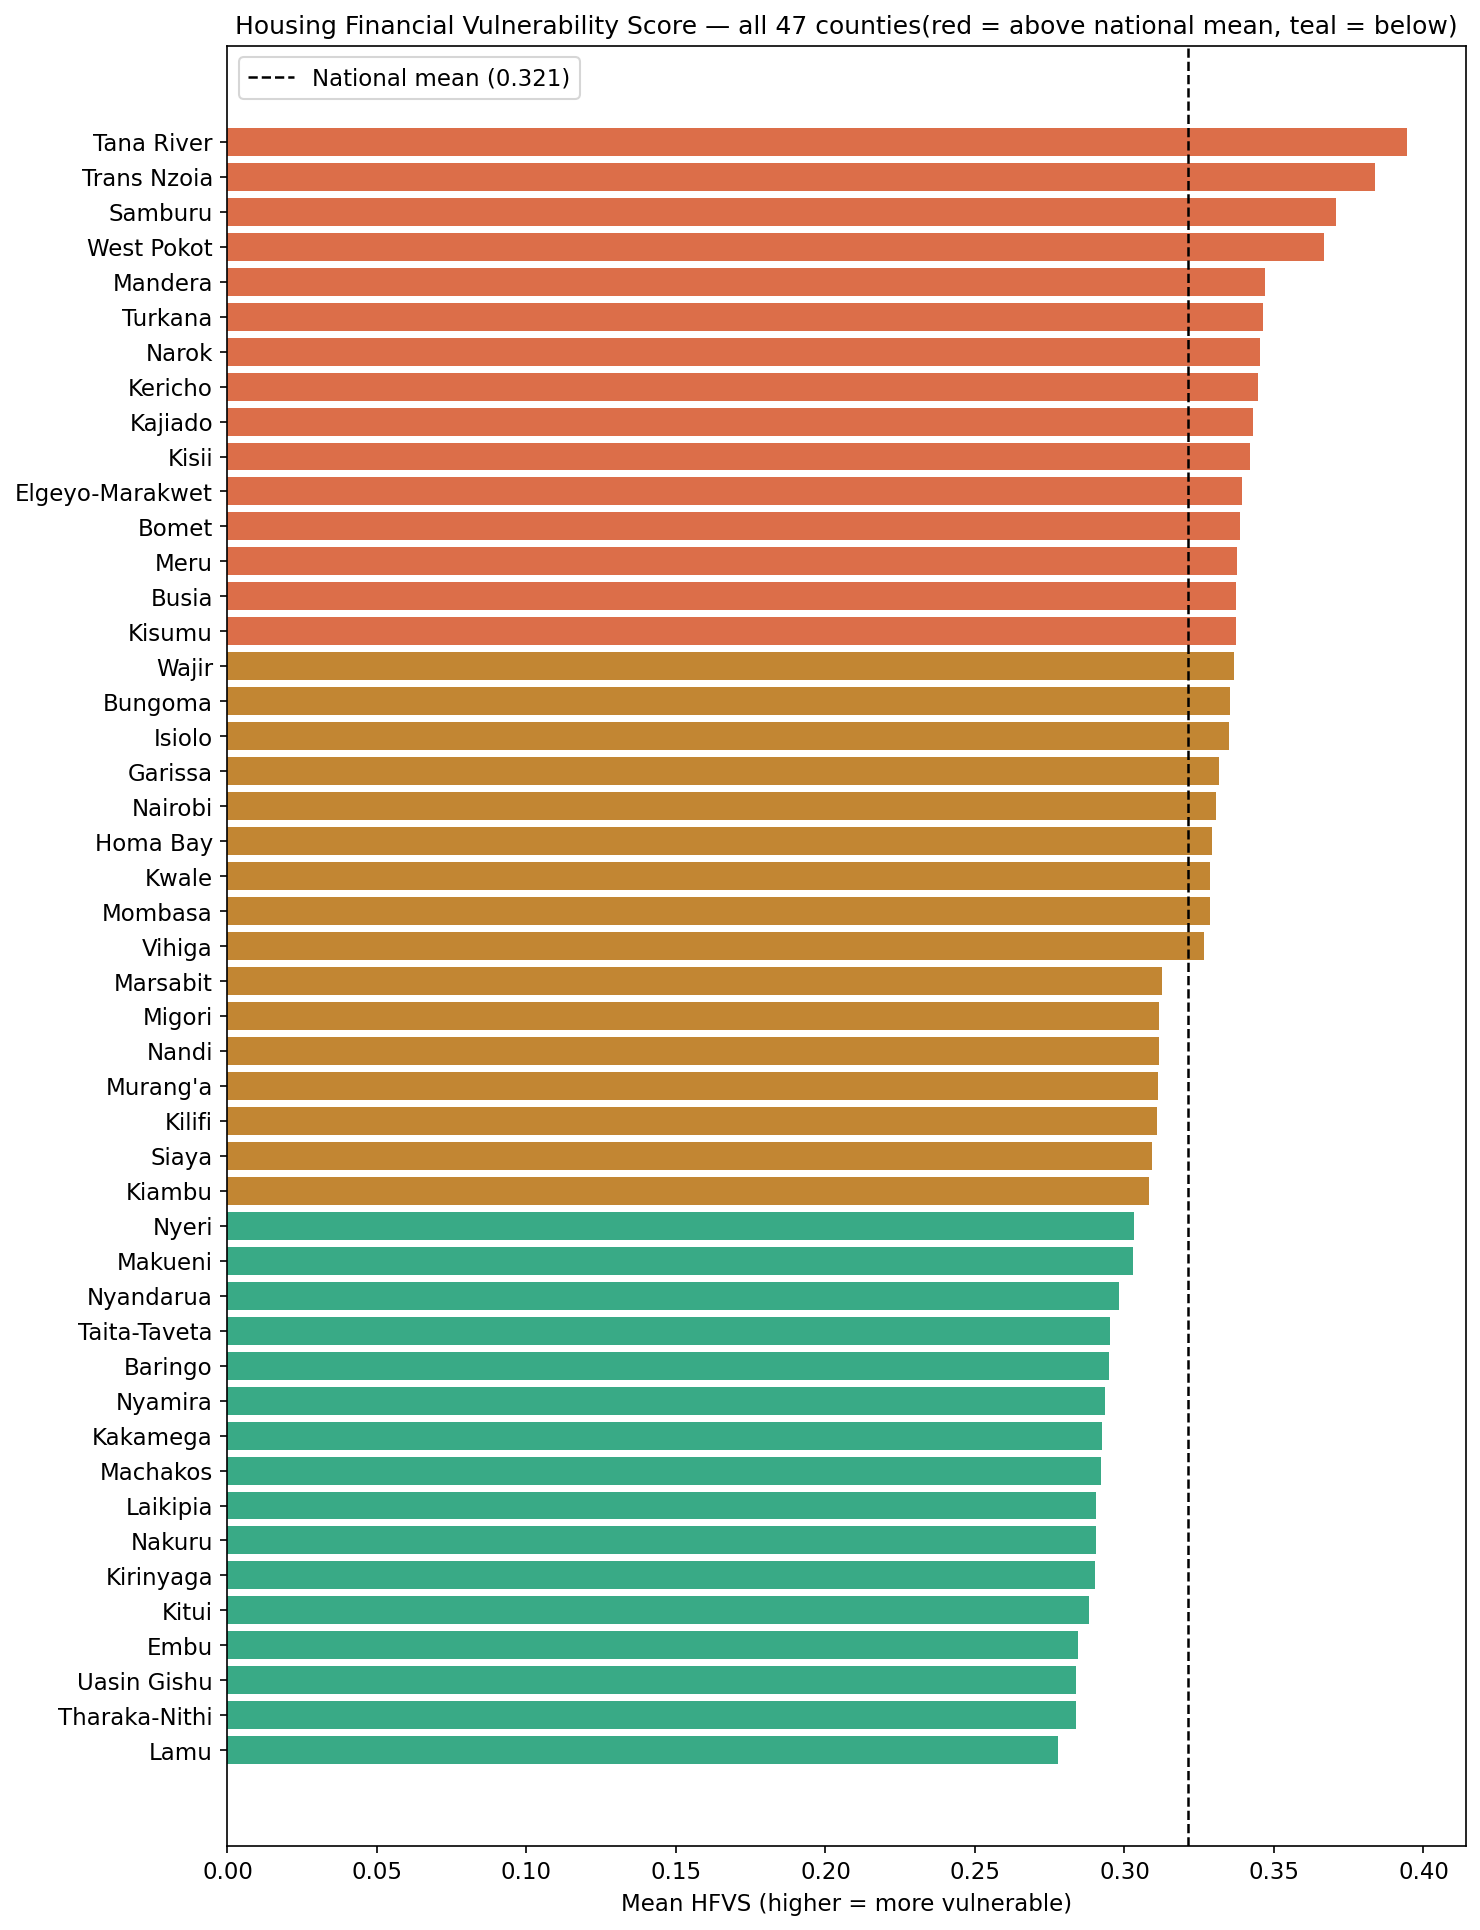

In [57]:
# ── Full 47-county HFVS bar chart ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 13))
c_sorted = county_agg.sort_values('mean_hfvs')
national_mean = y_cont.mean()
bar_colors = [RED if v > national_mean * 1.05 else
              TEAL if v < national_mean * 0.95 else
              AMBER for v in c_sorted['mean_hfvs']]

ax.barh(c_sorted['county_name'], c_sorted['mean_hfvs'],
        color=bar_colors, edgecolor='none', alpha=0.88)
ax.axvline(national_mean, color='black', linewidth=1.2, linestyle='--',
           label=f'National mean ({national_mean:.3f})')
ax.set_xlabel('Mean HFVS (higher = more vulnerable)')
ax.set_title('Housing Financial Vulnerability Score — all 47 counties'
             '(red = above national mean, teal = below)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / '04f_county_hfvs_named.png', dpi=150, bbox_inches='tight')
plt.show()


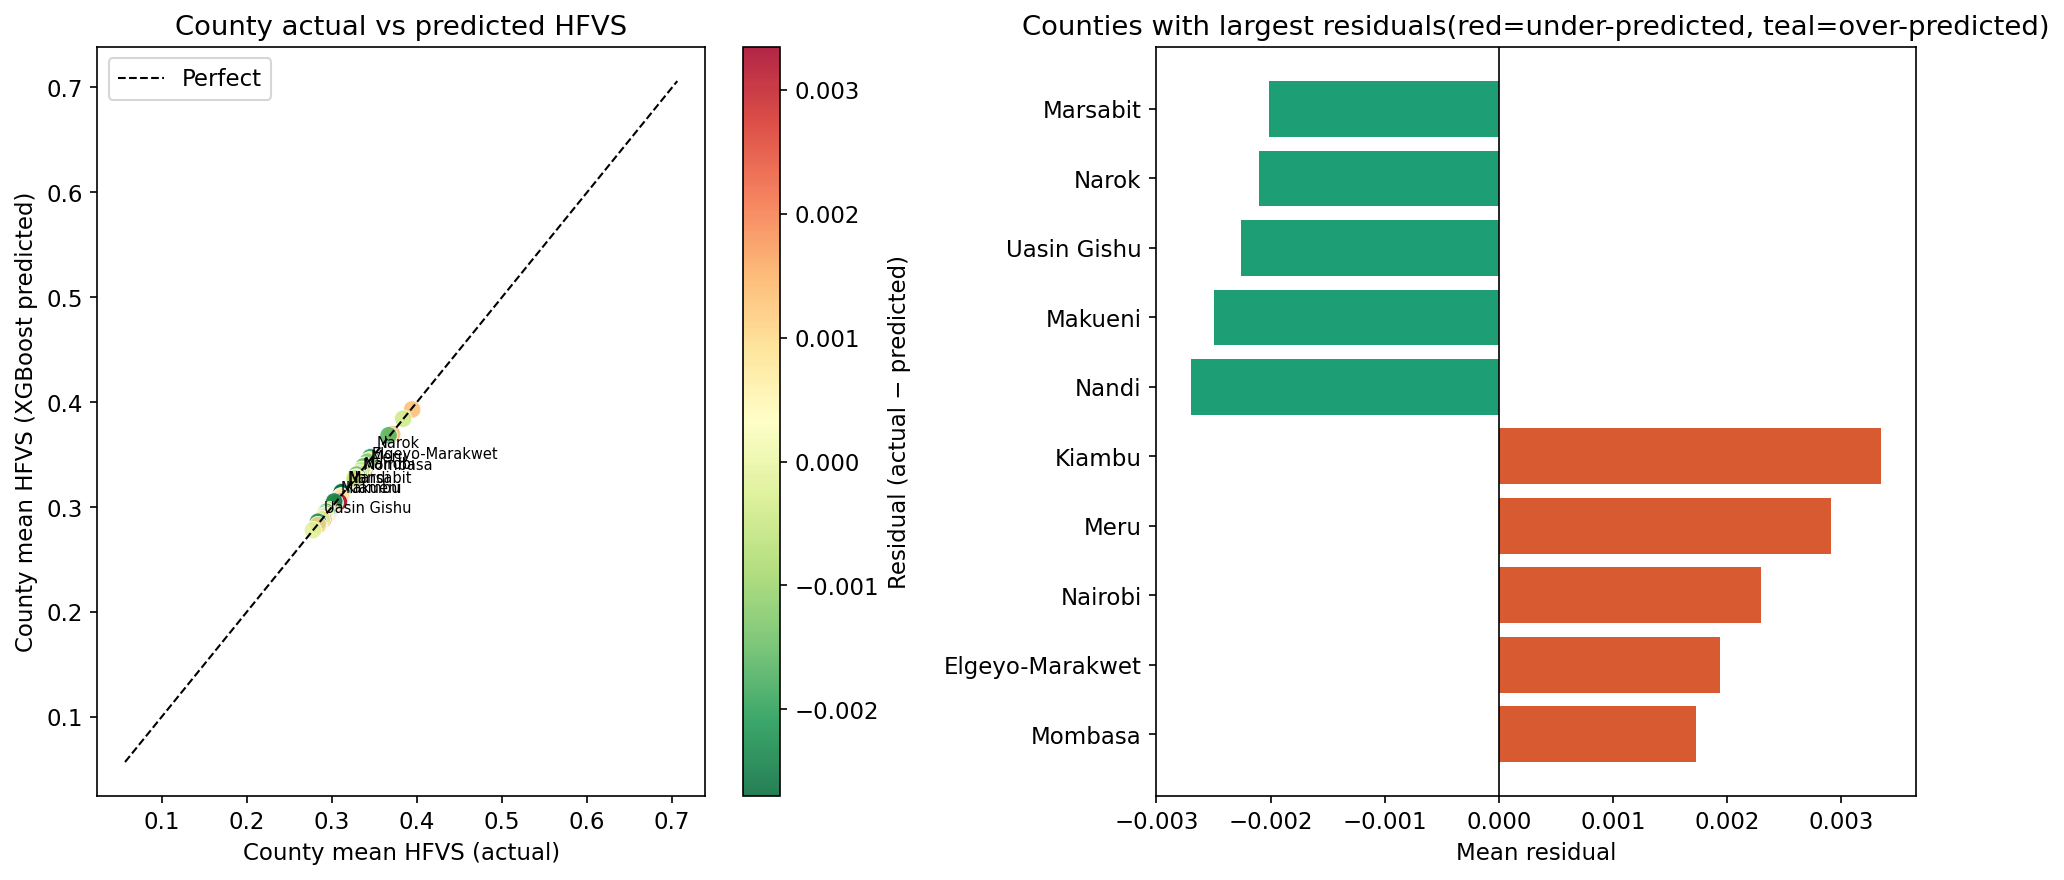

In [59]:
# ── County residual plot — where does the model struggle? ─────────────
resid_sorted = county_agg.sort_values('mean_residual')
top5_under   = resid_sorted.tail(5)    # model under-predicts (actual > pred)
top5_over    = resid_sorted.head(5)    # model over-predicts  (actual < pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Scatter: actual vs predicted
sc = axes[0].scatter(county_agg['mean_hfvs'], county_agg['mean_pred'],
                     c=county_agg['mean_residual'], cmap='RdYlGn_r',
                     s=70, alpha=0.85, edgecolors='white', linewidth=0.4)
axes[0].plot([y_cont.min(), y_cont.max()],
             [y_cont.min(), y_cont.max()], 'k--', lw=1, label='Perfect')
plt.colorbar(sc, ax=axes[0], label='Residual (actual − predicted)')
for _, row in pd.concat([top5_under, top5_over]).iterrows():
    axes[0].annotate(row['county_name'],
                     (row['mean_hfvs'], row['mean_pred']),
                     fontsize=7, ha='left', va='bottom',
                     xytext=(3, 3), textcoords='offset points')
axes[0].set_xlabel('County mean HFVS (actual)')
axes[0].set_ylabel('County mean HFVS (XGBoost predicted)')
axes[0].set_title('County actual vs predicted HFVS')
axes[0].legend()

# Residual bar — top/bottom 10
top10_resid = pd.concat([resid_sorted.tail(5), resid_sorted.head(5)])
colors_r    = [RED if r > 0 else TEAL for r in top10_resid['mean_residual']]
axes[1].barh(top10_resid['county_name'], top10_resid['mean_residual'],
             color=colors_r)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Counties with largest residuals'
                  '(red=under-predicted, teal=over-predicted)')
axes[1].set_xlabel('Mean residual')

plt.tight_layout()
plt.savefig(FIGS / '04g_county_residuals_named.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 15. TabNet Attention vs XGBoost SHAP — Dimension Alignment

Can deep learning independently recover your 5 theoretical HFVS dimensions
*without being told they exist?* This is the dissertation's key validation test.


In [60]:
DIM_PREFIXES = {
    'd1_financial_stress'   : ['rent_burden','savings_rate','no_savings','log_expenditure',
                                'log_rent','no_loan_access','high_rent_cost','has_investments'],
    'd2_tenure_insecurity'  : ['no_land_ownership','eviction_threat','no_written_lease',
                                'rent_dispute'],
    'd3_physical_hazard'    : ['flood','mudslide','high_risk_prox','near_swamp',
                                'near_dump','near_factory','near_busy','near_river','near_quarry'],
    'd4_dwelling_quality'   : ['floor_durable','wall_durable','roof_durable','structural',
                                'overcrowd','floor_area','informal','asbestos'],
    'd5_utility_deprivation': ['no_electricity','unsafe_water','poor_sanitation','solid_fuel'],
}

def assign_dim(feat):
    for dim, prefixes in DIM_PREFIXES.items():
        if any(feat.startswith(p) or p in feat for p in prefixes):
            return dim
    return 'other (spatial/demographic)'

att_df['dimension']      = att_df['feature'].apply(assign_dim)
shap_xgb_df['dimension'] = shap_xgb_df['feature'].apply(assign_dim)

tab_by_dim  = att_df.groupby('dimension')['attention_weight'].sum()
shap_by_dim = shap_xgb_df.groupby('dimension')['mean_abs_shap'].sum()

tab_norm  = tab_by_dim  / tab_by_dim.sum()
shap_norm = shap_by_dim / shap_by_dim.sum()

print("TabNet attention (normalised by dimension):")
print(tab_norm.sort_values(ascending=False).round(4))
print("\nXGBoost SHAP (normalised by dimension):")
print(shap_norm.sort_values(ascending=False).round(4))

common = list(set(tab_norm.index) & set(shap_norm.index))
rho_dim, p_dim = stats.spearmanr(
    [tab_norm.get(d, 0) for d in common],
    [shap_norm.get(d, 0) for d in common]
)
print(f"\nDimension rank concordance (TabNet vs XGBoost): ρ={rho_dim:.3f}  p={p_dim:.4f}")
if rho_dim > 0.60:
    print("→ Both models agree on dimension structure — validates HFVS framework.")
else:
    print("→ Models weight dimensions differently — a substantive methodological finding.")


TabNet attention (normalised by dimension):
dimension
other (spatial/demographic)    0.2477
d1_financial_stress            0.2162
d4_dwelling_quality            0.1621
d3_physical_hazard             0.1568
d2_tenure_insecurity           0.1480
d5_utility_deprivation         0.0692
Name: attention_weight, dtype: float64

XGBoost SHAP (normalised by dimension):
dimension
d1_financial_stress            0.2809
d4_dwelling_quality            0.2135
d3_physical_hazard             0.1973
d2_tenure_insecurity           0.1735
d5_utility_deprivation         0.1166
other (spatial/demographic)    0.0182
Name: mean_abs_shap, dtype: float32

Dimension rank concordance (TabNet vs XGBoost): ρ=0.143  p=0.7872
→ Models weight dimensions differently — a substantive methodological finding.


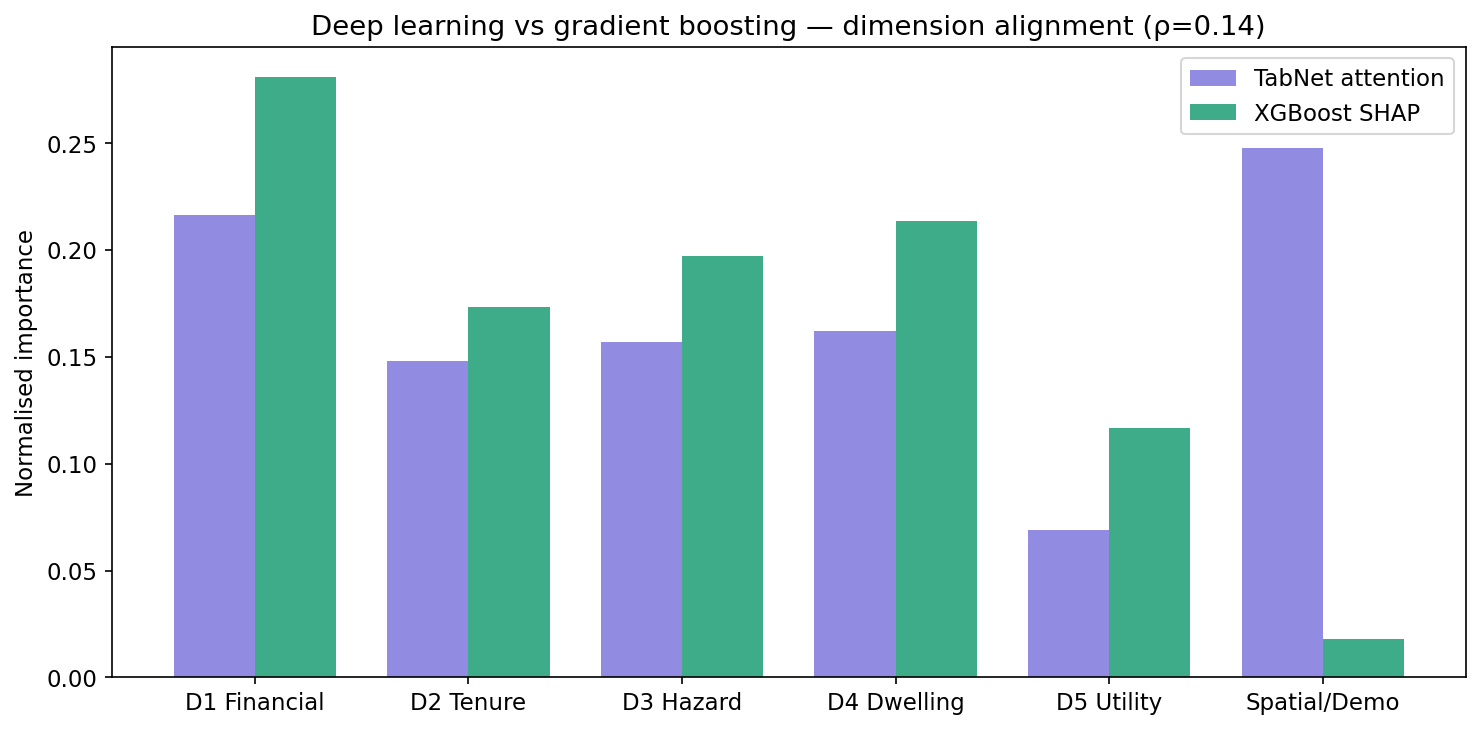

In [61]:
# ── Dimension alignment chart ─────────────────────────────────────────
DIM_ORDER  = list(DIM_PREFIXES.keys()) + ['other (spatial/demographic)']
DIM_LABELS = ['D1 Financial', 'D2 Tenure', 'D3 Hazard',
              'D4 Dwelling', 'D5 Utility', 'Spatial/Demo']

tab_vals  = [tab_norm.get(d, 0)  for d in DIM_ORDER]
shap_vals = [shap_norm.get(d, 0) for d in DIM_ORDER]

x = np.arange(len(DIM_LABELS))
w = 0.38
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, tab_vals,  w, label='TabNet attention', color=PURPLE, alpha=0.85)
ax.bar(x + w/2, shap_vals, w, label='XGBoost SHAP',     color=TEAL,   alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(DIM_LABELS)
ax.set_ylabel('Normalised importance')
ax.set_title(f'Deep learning vs gradient boosting — dimension alignment (ρ={rho_dim:.2f})')
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / '04h_dimension_alignment.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 16. Save Deployment Artefacts

The deployment notebook (notebook 05) will load these directly.
One model per task — no fold ensembling needed for deployment;
we use the full-data-fitted XGBoost (most stable, fastest inference).


In [63]:
import pickle, joblib

_xgb_reg_deploy = {k: v for k, v in xgb_reg_params.items()
                   if k != 'early_stopping_rounds'}
_xgb_cls_deploy = {k: v for k, v in xgb_cls_params.items()
                   if k != 'early_stopping_rounds'}

# ── Best model for deployment: XGBoost continuous (Track A) ───────────
xgb_deploy = xgb.XGBRegressor(**_xgb_reg_deploy)
xgb_deploy.fit(X_tree, y_cont)
xgb_deploy.save_model(str(MODS / 'xgb_deploy_continuous.json'))
print("Saved: xgb_deploy_continuous.json")

# XGBoost binary (for risk classification)
xgb_deploy_cls = xgb.XGBClassifier(**_xgb_cls_deploy)
xgb_deploy_cls.fit(X_tree, y_bin)
xgb_deploy_cls.save_model(str(MODS / 'xgb_deploy_binary.json'))
print("Saved: xgb_deploy_binary.json")

# ── Save feature list, scaler, county map ─────────────────────────────
artefacts = {
    'final_features'         : FINAL_FEATURES,
    'continuous_feats'       : CONTINUOUS_RAW,
    'binary_feats'           : BINARY_RAW,
    'county_map'             : COUNTY_MAP,
    'n_folds'                : N_FOLDS,
    'seed'                   : SEED,
    'hfvs_threshold_binary'  : float(np.quantile(y_cont, 0.60)),
    'model_version'          : 'v2',
}
with open(MODS / 'deployment_artefacts.json', 'w') as f:
    json.dump(artefacts, f, indent=2)
print("Saved: deployment_artefacts.json")

joblib.dump(scaler_nn, MODS / 'scaler_nn.pkl')
print("Saved: scaler_nn.pkl")

# ── OOF predictions for Chapter 5 spatial analysis ────────────────────
oof_df = pd.DataFrame({
    'interview__key': master['interview__key'],
    'county_code'   : county_id,
    'county_name'   : county_name,
    'hhweight'      : weight,
    'hfvs_actual'   : y_cont,
    'target_binary' : y_bin,
    'pred_xgb_cont' : oof_xgb_reg,
    'pred_xgb_bin'  : oof_xgb_cls,
    'pred_lgb_cont' : oof_lgb_reg,
    'pred_lgb_bin'  : oof_lgb_cls,
    'pred_tabnet'   : oof_tabnet,
    'pred_mlp'      : oof_mlp,
    'pred_logistic' : oof_lr,
})
pl.from_pandas(oof_df).write_parquet(PQ / 'oof_predictions_v2.parquet')
print(f"\nOOF predictions saved: {oof_df.shape}")
print("Ready for notebook 04 (county mapping + IRA validation).")

Saved: xgb_deploy_continuous.json
Saved: xgb_deploy_binary.json
Saved: deployment_artefacts.json
Saved: scaler_nn.pkl

OOF predictions saved: (21347, 13)
Ready for notebook 04 (county mapping + IRA validation).


In [64]:
# ── Final summary ─────────────────────────────────────────────────────
print("\n" + "="*70)
print("FINAL RESULTS — v2 (Track A: raw features, no leakage)")
print("="*70)

a_rows = comp_df[comp_df['track']=='A'].copy()
print("\n── BINARY CLASSIFICATION ─────────────────────────────────────────")
cls_out = a_rows[a_rows['AUC_ROC'].notna()][['model','AUC_ROC','PR_AUC','F1']]
print(cls_out.to_string(index=False))

print("\n── CONTINUOUS REGRESSION ─────────────────────────────────────────")
reg_out = a_rows[a_rows['R2'].notna()][['model','RMSE','MAE','R2']]
print(reg_out.to_string(index=False))

print("\n── INTERPRETABILITY ──────────────────────────────────────────────")
print(f"  XGBoost vs LightGBM SHAP concordance : ρ={rho_shap:.3f}")
print(f"  TabNet vs XGBoost dimension alignment : ρ={rho_dim:.3f}")
print(f"  Logistic top coefficient              : {coef_df.iloc[0]['feature']} "
      f"(OR={coef_df.iloc[0]['odds_ratio']:.2f})")

print("\n── DEPLOYMENT ARTEFACTS SAVED ────────────────────────────────────")
print(f"  {MODS}/xgb_deploy_continuous.json")
print(f"  {MODS}/xgb_deploy_binary.json")
print(f"  {MODS}/deployment_artefacts.json")
print(f"  {MODS}/scaler_nn.pkl")
print(f"  {PQ}/oof_predictions_v2.parquet")



FINAL RESULTS — v2 (Track A: raw features, no leakage)

── BINARY CLASSIFICATION ─────────────────────────────────────────
          model  AUC_ROC   PR_AUC       F1
logistic_binary 0.983175 0.977303 0.907222
     xgb_binary 0.988845 0.985052 0.928638
     lgb_binary 0.989177 0.985321 0.928871

── CONTINUOUS REGRESSION ─────────────────────────────────────────
            model     RMSE      MAE       R2
   xgb_continuous 0.015114 0.010952 0.969560
   lgb_continuous 0.015124 0.010930 0.969520
tabnet_continuous 0.022659 0.016075 0.931577
   mlp_continuous 0.018788 0.014101 0.952959

── INTERPRETABILITY ──────────────────────────────────────────────
  XGBoost vs LightGBM SHAP concordance : ρ=0.986
  TabNet vs XGBoost dimension alignment : ρ=0.143
  Logistic top coefficient              : no_land_ownership (OR=24.60)

── DEPLOYMENT ARTEFACTS SAVED ────────────────────────────────────
  /content/drive/MyDrive/KHS_Dissertation/outputs/models/v2/xgb_deploy_continuous.json
  /content/drive/M

---
## 17. Push to GitHub

In [ ]:
!git config user.email "gronjerono@gmail.com"
!git config user.name "VAL-Jerono"
!git add notebooks/ outputs/
!git status


In [ ]:
!git commit -m "feat(03v2): improved modelling — leakage fix, raw features only, county names, TabNet+MLP tuned, deployment artefacts"
!git push origin main
